##### DCGAN with Animals Dataset

We have performed various experiments with training of GANs. \
Only stable experiments are listed as below: 
| Experiment # | Question # | Model Type          | Dataset Description                     | Key Parameters (e.g., Batch Size, Learning Rate) | Results (e.g., FID Score, Epochs) | Notes/Observations                              |
|--------------|------------|---------------------|------------------------------------------|-------------------------------------------------|----------------------------------|------------------------------------------------|
| 1            | Q1,Q2       | DCGAN  with Discriminator trained once w.r.t. Generator              |Animal Images, 90 classes | Batch Size: 64, Learning Rate: 0.0002            | FID: 163.83, 23000 iterations      | Images was clearer after 11000 iterations       |
| 2            | Q3   Exp 1    | DCGAN  with Discriminator trained 3 times; Generator trained 1 time      |Animal Images, 90 classes | Batch Size: 128, Learning Rate: 0.0002            | FID: 202.23      | Stable training but image quality detoriated, may be because of overpowering of discriminator caused fewer updates in generator.  |
| 3            | Q3  Exp 2    |DCGAN  with Discriminator trained 5 times; Generator trained 1 time  | Animal Images, 90 classes  | Batch Size: 128, Learning Rate: 0.0002,| FID: 282.36   |Same as above|
| 4            | Q3  Exp 3       |DCGAN  with Generator trained 5 times; Discriminator trained 1 time  | Animal Images, 90 classes  | Batch Size: 128, Learning Rate: 0.0002, | FID: 228.612      | Training becomes unstable, discriminator becomes weaker, noisy image generated Generator and Discriminator is getting stagnent at some point and not learning further (Vanishing Gradients Problem), Generated Noisy Images|


In [100]:
import os
import torch
import random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision.utils as vutils
from torchvision.utils import save_image

In [101]:
path = os.path.join(os.getcwd(), 'data','augmented_animals')
workers = 8
batch_size = 64
image_size = 128
nc = 3
latent_dim = 100
gen_feature = 128
dis_feature = 128
num_epochs = 60
lrd = 0.0002
lrg = 0.0002
beta1 = 0.5
ngpu = 1
device = torch.device("cuda" if (torch.cuda.is_available() and ngpu > 0) else "cpu")


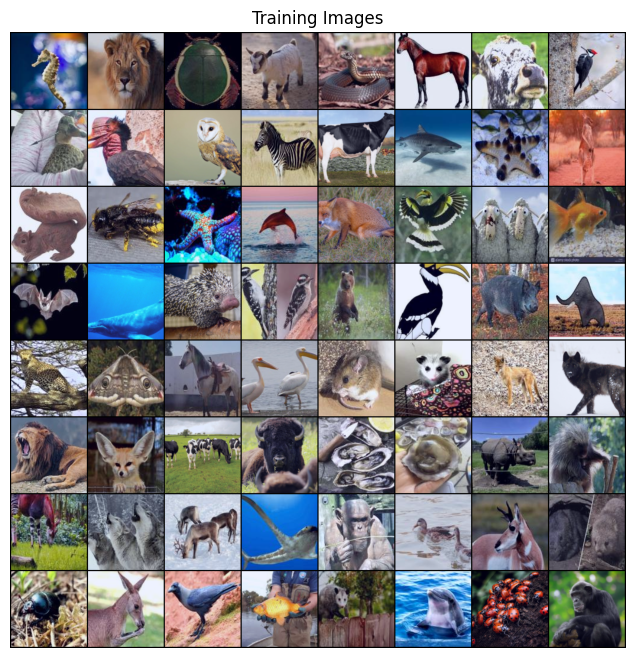

In [102]:
# We can use an image folder dataset the way we have it setup.
# Create the dataset
mean = torch.tensor([0.50869316, 0.50057036, 0.44047505])
std = torch.tensor([0.20191325, 0.19737212, 0.20100889])
dataset = datasets.ImageFolder(root=path,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize(mean,std),
                           ]))
# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# Decide which device we want to run on

# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [103]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [104]:
class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            self.generator_block(latent_dim, gen_feature * 8, 4, 1, 0),
            # state size. (gen_feature*8) x 4 x 4
            self.generator_block(gen_feature * 8, gen_feature * 4, 4, 2, 1),
            # state size. (gen_feature*4) x 8 x 8
            self.generator_block(gen_feature * 4, gen_feature * 2, 4, 2, 1),
            # state size. (gen_feature*2) x 16 x 16
            self.generator_block(gen_feature * 2, gen_feature, 4, 2, 1),
            # state size. (gen_feature) x 32 x 32
            self.generator_block(gen_feature , gen_feature//2, 4, 2, 1),
            # state size. (gen_feature) x 64 x 64
            nn.ConvTranspose2d(gen_feature // 2, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 128 x 128
        )

    def generator_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True)
        )

    def forward(self, input):
        return self.main(input)

In [105]:
# Create the generator
netG = Generator(ngpu).to(device)
netG.apply(weights_init)


Generator(
  (main): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
      (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (3): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inpl

In [106]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is (nc) x 128 x 128
            nn.Conv2d(nc, dis_feature//2, 4, 2, 1, bias=False),
            # input is (nc) x 64 x 64
            self.discriminator_block(dis_feature//2, dis_feature, 4, 2, 1),
            # state size. (dis_feature) x 32 x 32
            self.discriminator_block(dis_feature, dis_feature * 2, 4, 2, 1),
            # state size. (dis_feature*2) x 16 x 16
            self.discriminator_block(dis_feature * 2, dis_feature * 4, 4, 2, 1),
            # state size. (dis_feature*4) x 8 x 8
            self.discriminator_block(dis_feature * 4, dis_feature * 8, 4, 2, 1),
            # state size. (dis_feature*8) x 4 x 4
            nn.Conv2d(dis_feature * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def discriminator_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )
    def forward(self, input):
        return self.main(input)

In [107]:
# Create the Discriminator
netD = Discriminator(ngpu).to(device)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (4): Sequential(
      (0): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2)

In [108]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(100, latent_dim, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 0.9
fake_label = 0.0

# Setup Adam optimizers for both G and D
optimizerD = Adam(netD.parameters(), lr=lrd, betas=(beta1, 0.999))
optimizerG = Adam(netG.parameters(), lr=lrg, betas=(beta1, 0.999))

In [ ]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        ##########################
        # Discriminator Training #
        ##########################
        ## Train with real data
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # pass real data from discriminator
        output = netD(real_cpu).view(-1)
        # disciminator loss due to real data
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with fake data
        # Sample from normal distribution
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        # Gene
        # rate fake image
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ######################
        # Generator Training #
        ######################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake,nrow=10, padding=2, normalize=True))
            save_image(img_list[-1], 'output/{}.png'.format(iters),  normalize=True)
        iters += 1

# Save the model
save_generator_name = 'new_dcgan_generator.pth'
torch.save(netG, save_generator_name)



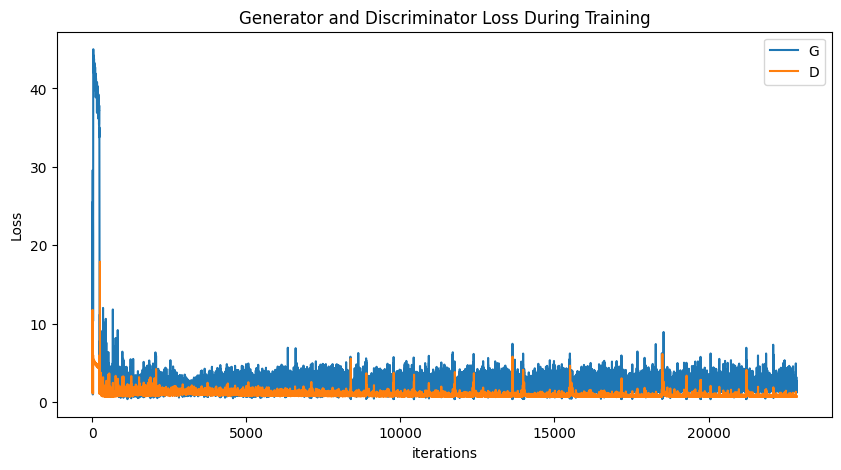

In [87]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

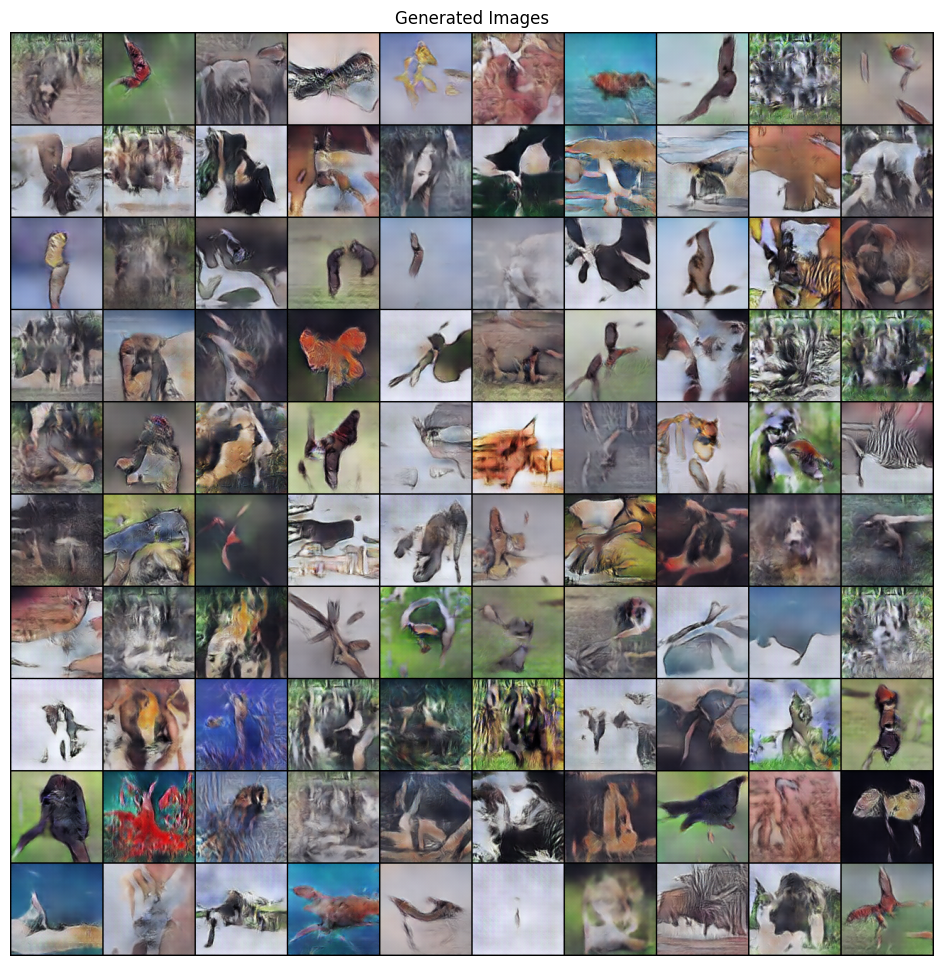

In [88]:
# Load the model
model = torch.load(save_generator_name,weights_only=False)
model.eval()
# Generate some fake images
fixed_noise = torch.randn(100, latent_dim, 1, 1, device=device)
plt.figure(figsize=(12,12))

with torch.no_grad():
    fake = model(fixed_noise).detach().cpu()
    plt.imshow(np.transpose(vutils.make_grid(fake,nrow=10,padding=2, normalize=True).cpu(),(1,2,0)))
    plt.title("Generated Images")
    plt.axis('off')
    plt.show()

FID Calculation

In [89]:
import numpy as np
fake_images = []

for i in range(1000):
    noise = torch.randn(1, latent_dim, 1, 1).to(device)
    img = model(noise).detach().cpu().numpy().squeeze()
    # 0 to 1 normalization
    img = (img - img.min()) / (img.max() - img.min())
    fake_images.append(img)
fake_images = np.array(fake_images)
# 1000 real fake_images in tensor format
real_images = []
# sample 1000 images from the training set
for i in range(1000):
    img = dataset[i][0].numpy().squeeze()
    # 0 to 1 normalization
    img = (img - img.min()) / (img.max() - img.min())
    real_images.append(img)


import torch
from torcheval.metrics import FrechetInceptionDistance

# Assuming you have real and fake images as tensors
# real_images: Tensor of shape (1000, 3, 128, 128)
# fake_images: Tensor of shape (1000, 3, 128, 128)

# Initialize FID metric calculator
fid_metric = FrechetInceptionDistance(feature_dim=2048)  # FID is typically computed using Inception-V3 features with 2048 dimensions
# normalize the images

# Update the FID metric with real and fake images
fid_metric.update(torch.tensor(real_images), is_real=True)
fid_metric.update(torch.tensor(fake_images), is_real=False)

# Compute the FID score
fid_score = fid_metric.compute()

print(f"FID Score: {fid_score.item()}")

FID Score: 163.83697509765625


#### Q1,Q2 Learnings: 

Images are clear and diverse but animal is not identifiable. \
Reason may be more features like background, shape of animal etc. to be learned by model which is possible if larger data and more powerful model is used. \
Above results are with data augmentation of three times the actual data (180 images each of 90 class).